In [18]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import soundfile as sf
from tqdm import tqdm
import librosa
import soundfile as sf
from matplotlib import pyplot as plt

In [19]:
def resample(path, new_sr=22050):
    y, sr = librosa.load(path, sr=None)
    y_resampled = librosa.resample(y, orig_sr=sr, target_sr=new_sr)

    return y_resampled

In [20]:
def normalize_signal(y):
    max_amplitude = np.max(np.abs(y))
    
    return y / max_amplitude

In [21]:
def envelope(y, threshold=0.1, sr=22050):
    mask = []
    y = pd.Series(y).apply(np.abs)
    y_mean = y.rolling(window=int(sr/20),
                       min_periods=1,
                       center=True).max()
    
    for mean in y_mean:
        if mean > threshold:
            mask.append(True)
        else:
            mask.append(False)

    return mask, y_mean

In [22]:
def remove_silence_using_mask(y, threshold=0.1, sr=22050):
    mask, _ = envelope(y, threshold, sr)
    new_signal = []

    for i, val in enumerate(y):
        if mask[i]:
            new_signal.append(val)
            
    return np.array(new_signal)

In [23]:
def segment_signal(y, delta_time=1, sr=22050):
    segment_length = int(delta_time * sr)
    segments = [y[i:i + segment_length] for i in range(0, len(y), segment_length)]
    
    fixed_segments = []
    for segment in segments:
        if len(segment) < segment_length:
            fixed_segments.append(np.pad(segment, (0, segment_length - len(segment)), mode='constant', constant_values=0))
        else:
            fixed_segments.append(segment)

    return fixed_segments

In [ ]:
def create_clean_dir(df, origin_dir, clean_dir, segmented_dir, override=False, threshold=0.1, delta_time = 1, sr=22050):
    origin_dir = Path(origin_dir)
    clean_dir = Path(clean_dir)
    segmented_dir = Path(segmented_dir)
    if not origin_dir.exists() or not any(origin_dir.glob('*.wav')):
        raise FileNotFoundError(
            f"Kaggle raw audio files not found in {origin_dir}. "
            "Download the Kaggle `.wav` files and place them in this folder before running preprocessing."
        )

    if not any(origin_dir.glob('*.wav')):
        raise FileNotFoundError(
            f"No raw WAV files found in {origin_dir}. "
            "Ensure the Kaggle raw audio files are present before running preprocessing."
        )

    if clean_dir.exists() and any(clean_dir.iterdir()):
        print('Clean directory isn\'t empty')
        if not override:
            return
    clean_dir.mkdir(parents=True, exist_ok=True)
    if segmented_dir.exists() and any(segmented_dir.iterdir()):
        print('Segmented directory isn\'t empty')
        if not override:
            return
    segmented_dir.mkdir(parents=True, exist_ok=True)

    tqdm._instances.clear()

    for f in tqdm(df.fname):
        y = resample(origin_dir / f, sr)
        normalized_y = normalize_signal(y)
        cleaned_signal = remove_silence_using_mask(normalized_y, threshold, sr)
        segments = segment_signal(cleaned_signal, delta_time, sr)
        sf.write(clean_dir / f, cleaned_signal, sr)

        for i, segment in enumerate(segments):
            if len(segment) >= delta_time * sr:
                segment_filename = Path(f).stem + f'_{i}.wav'
                sf.write(segmented_dir / segment_filename, segment, sr)

Load train/test DataFrame


In [ ]:
train_csv_path = '../../data/meta/train_post_competition.csv'
train_csv_path = Path('../../data/meta/train_post_competition.csv')
if not train_csv_path.exists():
    raise FileNotFoundError(
        f"Kaggle metadata file not found: {train_csv_path}. "
        "Download and extract `FSDKaggle2018.meta.zip` into code/kaggle/data/meta/."
    )
train_df = pd.read_csv(train_csv_path)

In [26]:
# musical_instruments = [
#     'Hi-hat', 'Saxophone', 'Trumpet', 'Glockenspiel', 'Cello', 'Knock',
#     'Gunshot_or_gunfire', 'Clarinet', 'Computer_keyboard',
#     'Keys_jangling', 'Snare_drum', 'Writing', 'Laughter', 'Tearing',
#     'Fart', 'Oboe', 'Flute', 'Cough', 'Telephone', 'Bark', 'Chime',
#     'Bass_drum', 'Bus', 'Squeak', 'Scissors', 'Harmonica', 'Gong',
#     'Microwave_oven', 'Burping_or_eructation', 'Double_bass',
#     'Shatter', 'Fireworks', 'Tambourine', 'Cowbell', 'Electric_piano',
#     'Meow', 'Drawer_open_or_close', 'Applause', 'Acoustic_guitar',
#     'Violin_or_fiddle', 'Finger_snapping'
# ]

musical_instruments = [
    'Hi-hat', 'Saxophone', 'Trumpet', 'Glockenspiel', 'Cello', 
    'Clarinet', 'Oboe', 'Flute', 'Bass_drum', 'Double_bass',
    'Tambourine', 'Cowbell', 'Electric_piano', 'Harmonica', 
    'Acoustic_guitar', 'Violin_or_fiddle'
]

train_df = train_df[train_df['label'].isin(musical_instruments)]

In [27]:
print(len(train_df))

4120


In [28]:
train_df = train_df[train_df['fname'].apply(lambda x: os.path.exists(os.path.join('../../data/raw', x)))]
train_df = train_df[train_df['manually_verified'] == 1]
train_df = train_df.reset_index(drop=True)

In [29]:
print(len(train_df))
print(train_df.label.value_counts().sort_index())

1847
label
Acoustic_guitar     105
Bass_drum            67
Cello               125
Clarinet            130
Cowbell              96
Double_bass          92
Electric_piano       74
Flute               128
Glockenspiel         70
Harmonica            88
Hi-hat               89
Oboe                 99
Saxophone           256
Tambourine           92
Trumpet              86
Violin_or_fiddle    250
Name: count, dtype: int64


Create clean directories


In [ ]:
create_clean_dir(train_df, '../../data/raw', '../../data/clean', '../../data/segmented', override=True, threshold=0.1, delta_time=1, sr=22050)

100%|██████████| 1847/1847 [01:11<00:00, 25.98it/s]


Plot envelope


In [31]:
def plot_envelope(df, origin_dir, i=0, threshold=0.1, sr=22050, save_path=None):
    origin_dir = Path(origin_dir)
    y = resample(origin_dir / df.fname[i], sr)
    y_normalized = normalize_signal(y)
    mask, mean = envelope(y_normalized, threshold, sr)
    mask = np.array(mask)
    y_remove = np.copy(y_normalized)
    y_remove[mask] = np.nan
    y_keep = np.copy(y_normalized)
    y_keep[~mask] = np.nan
    plt.title('Signal Envelope | Threshold = {}'.format(str(threshold)))
    plt.xlabel('Time')
    plt.ylabel('Signal Amplitude')
    plt.plot(mean, color='m', label='envelope')
    plt.plot(y_remove, color='r', label='remove')
    plt.plot(y_keep, color='c', label='keep')
    plt.legend(loc='best')
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)  
    plt.show()

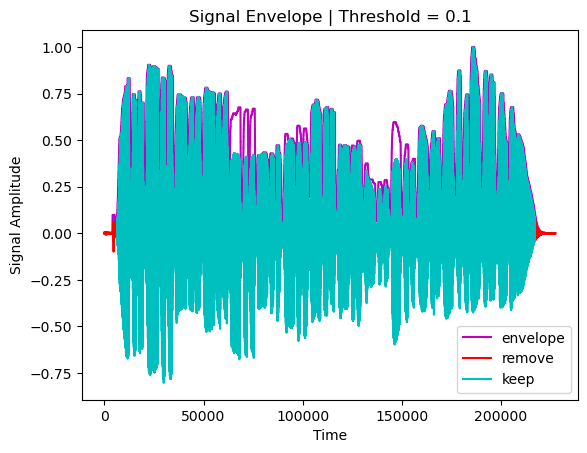

In [32]:
plot_envelope(train_df, '../../data/raw', 0, 0.1, 22050, '../../images/envelope')

Plot mel spectrogram


In [33]:
def plot_melspectrogram(df, clean_dir, i=0, n_mels=128):
    clean_dir = Path(clean_dir)
    y, sr = librosa.load(clean_dir / df.fname[i], sr=None)
    melspectrogram = librosa.feature.melspectrogram(y=y, 
                                                    sr=sr, 
                                                    n_mels=n_mels, 
                                                    fmax=sr/2)
    melspectrogram_db = librosa.power_to_db(melspectrogram, ref=np.max)
    librosa.display.specshow(melspectrogram_db, x_axis='time', y_axis='mel', cmap='viridis')
    plt.colorbar(label='Amplitude')
    plt.title('Mel Spectrogram')
    plt.xlabel('Time Frames')
    plt.ylabel('Mel Frequency Bands')
    plt.show()

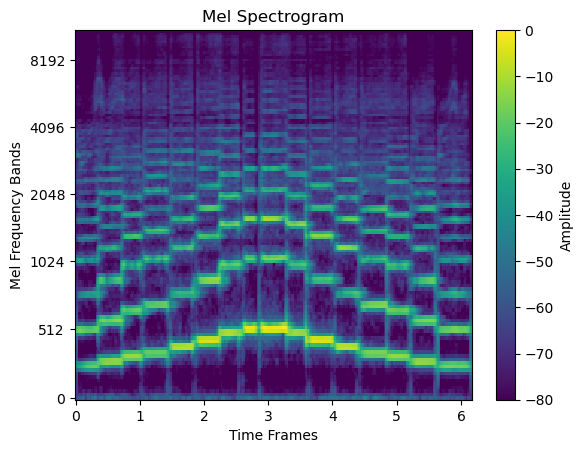

In [34]:
i = 5

plot_melspectrogram(train_df, '../../data/clean', i)